# Air Quality and Pollution Pattern Analysis

**Dataset:** UCI Air Quality Dataset (`AirQualityUCI.csv`)  
**Source:** https://archive.ics.uci.edu/dataset/360/air+quality  

This project uses Pandas, NumPy, and Matplotlib to clean, prepare, analyze, and visualize a real environmental dataset collected from an air-quality monitoring system.

## Analytical Questions

1. How do major pollutants vary over time?
2. Which hours of the day show the highest pollution levels?
3. How are temperature and humidity related to pollutant concentration?
4. Which sensor readings and pollutant variables are most strongly correlated?
5. Are there unusual high-pollution records that should be treated as outliers?

In [27]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

DATA_URL = 'https://archive.ics.uci.edu/static/public/360/air+quality.zip'
DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')
ZIP_PATH = DATA_DIR / 'air_quality.zip'
CSV_PATH = DATA_DIR / 'AirQualityUCI.csv'

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

## Load Dataset

In [28]:
if not CSV_PATH.exists():
    urlretrieve(DATA_URL, ZIP_PATH)
    with ZipFile(ZIP_PATH) as zip_file:
        zip_file.extract('AirQualityUCI.csv', DATA_DIR)

raw_df = pd.read_csv(CSV_PATH, sep=';', decimal=',')

print('Dataset source: UCI Machine Learning Repository - Air Quality Dataset')
print('Original shape:', raw_df.shape)
raw_df.head()

Dataset source: UCI Machine Learning Repository - Air Quality Dataset
Original shape: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## Requirement Check

The dataset is real, comes from the UCI Machine Learning Repository, has more than 1,000 rows, has more than 6 columns, includes date/time information, contains numeric pollution and weather variables, and includes missing values marked by `-200`.

In [29]:
print('Rows:', raw_df.shape[0])
print('Columns:', raw_df.shape[1])
print('Column names:', raw_df.columns.tolist())
print('Missing marker (-200) count:', int((raw_df == -200).sum(numeric_only=True).sum()))

Rows: 9471
Columns: 17
Column names: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']
Missing marker (-200) count: 16701


## Data Cleaning

In [30]:
df = raw_df.copy()

# Remove empty columns created by trailing separators in the original CSV.
df = df.dropna(axis=1, how='all')

# Remove blank rows, replace the dataset's missing-value marker, and parse date/time.
df = df.dropna(subset=['Date', 'Time'])
df = df.replace(-200, np.nan)
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'].str.replace('.', ':', regex=False),
    dayfirst=True,
    errors='coerce'
)
df = df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

df = df.rename(columns={
    'CO(GT)': 'co_gt',
    'PT08.S1(CO)': 'sensor_co',
    'NMHC(GT)': 'nmhc_gt',
    'C6H6(GT)': 'benzene_gt',
    'PT08.S2(NMHC)': 'sensor_nmhc',
    'NOx(GT)': 'nox_gt',
    'PT08.S3(NOx)': 'sensor_nox',
    'NO2(GT)': 'no2_gt',
    'PT08.S4(NO2)': 'sensor_no2',
    'PT08.S5(O3)': 'sensor_o3',
    'T': 'temperature_c',
    'RH': 'relative_humidity',
    'AH': 'absolute_humidity'
})

df['date'] = df['datetime'].dt.date
df['month'] = df['datetime'].dt.to_period('M').astype(str)
df['hour'] = df['datetime'].dt.hour
df['day_name'] = df['datetime'].dt.day_name()
df['is_weekend'] = df['datetime'].dt.dayofweek >= 5

pollutant_columns = ['co_gt', 'benzene_gt', 'nox_gt', 'no2_gt']
sensor_columns = ['sensor_co', 'sensor_nmhc', 'sensor_nox', 'sensor_no2', 'sensor_o3']
weather_columns = ['temperature_c', 'relative_humidity', 'absolute_humidity']

missing_summary = (
    df[pollutant_columns + sensor_columns + weather_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame('missing_percent')
)

df_clean = df.copy()
for column in pollutant_columns + sensor_columns + weather_columns:
    df_clean[column] = df_clean[column].interpolate(limit_direction='both')

pollution_score = df_clean[pollutant_columns].apply(lambda s: (s - s.mean()) / s.std())
df_clean['pollution_score'] = pollution_score.mean(axis=1)
df_clean['pollution_level'] = pd.qcut(
    df_clean['pollution_score'],
    q=4,
    labels=['Low', 'Moderate', 'High', 'Very high']
)
z_scores = (df_clean['pollution_score'] - np.mean(df_clean['pollution_score'])) / np.std(df_clean['pollution_score'])
df_clean['pollution_z_score'] = z_scores
df_clean['is_pollution_outlier'] = np.abs(z_scores) > 3

print('Cleaned shape:', df_clean.shape)
print('Date range:', df_clean['datetime'].min(), 'to', df_clean['datetime'].max())
print('Pollution outlier rows:', int(df_clean['is_pollution_outlier'].sum()))
missing_summary

Cleaned shape: (9357, 25)
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Pollution outlier rows: 105


,missing_percent
co_gt,17.986534
no2_gt,17.548360
nox_gt,17.516298
benzene_gt,3.911510
sensor_co,3.911510
sensor_nmhc,3.911510
sensor_nox,3.911510
sensor_no2,3.911510
sensor_o3,3.911510
temperature_c,3.911510


## Feature Engineering

In [31]:
df_clean['temperature_band'] = pd.cut(
    df_clean['temperature_c'],
    bins=[-10, 10, 20, 30, 50],
    labels=['Cold', 'Mild', 'Warm', 'Hot']
)
df_clean['humidity_band'] = pd.cut(
    df_clean['relative_humidity'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)
df_clean['rush_period'] = np.select(
    [
        df_clean['hour'].between(7, 10),
        df_clean['hour'].between(17, 20)
    ],
    ['Morning rush', 'Evening rush'],
    default='Other'
)

df_clean[['datetime', 'hour', 'temperature_band', 'humidity_band', 'rush_period', 'pollution_level']].head()

,datetime,hour,temperature_band,humidity_band,rush_period,pollution_level
0,2004-03-10 18:00:00,18,Mild,Medium,Evening rush,High
1,2004-03-10 19:00:00,19,Mild,Medium,Evening rush,Moderate
2,2004-03-10 20:00:00,20,Mild,Medium,Evening rush,High
3,2004-03-10 21:00:00,21,Mild,Medium,Other,High
4,2004-03-10 22:00:00,22,Mild,Medium,Other,Moderate


## Time-Based Pollution Patterns

In [32]:
monthly_pollution = df_clean.groupby('month')[pollutant_columns + ['pollution_score']].mean()
hourly_pollution = df_clean.groupby('hour')[pollutant_columns + ['pollution_score']].mean()
rush_pollution = df_clean.groupby('rush_period')[pollutant_columns + ['pollution_score']].mean().sort_values('pollution_score', ascending=False)
weekend_pollution = df_clean.groupby('is_weekend')[pollutant_columns + ['pollution_score']].mean()

monthly_pollution.to_csv(OUTPUT_DIR / 'monthly_pollution_trend.csv')
hourly_pollution.to_csv(OUTPUT_DIR / 'hourly_pollution_pattern.csv')
rush_pollution.to_csv(OUTPUT_DIR / 'rush_period_pollution.csv')
weekend_pollution.to_csv(OUTPUT_DIR / 'weekend_pollution_comparison.csv')

hourly_pollution

,co_gt,benzene_gt,nox_gt,no2_gt,pollution_score
hour,,,,,
0,1.846334,7.849924,198.104375,102.755965,-0.217853
1,1.567172,6.235825,169.406229,91.701694,-0.414969
2,1.262307,4.705032,136.469005,78.751202,-0.629188
3,1.079787,3.749138,120.142474,71.485986,-0.751974
4,0.991097,3.313700,104.496713,64.505385,-0.838672
5,0.946595,3.467815,109.477634,65.380538,-0.830505
6,1.122774,5.101730,142.674707,75.786878,-0.648692
7,1.857740,10.549490,227.510308,95.486228,-0.129056
8,2.729271,15.854943,330.172404,118.443270,0.449025


## Weather and Correlation Analysis

In [33]:
weather_pollution = (
    df_clean
    .groupby(['temperature_band', 'humidity_band'], observed=True)[pollutant_columns + ['pollution_score']]
    .mean()
    .sort_values('pollution_score', ascending=False)
)

correlation_columns = pollutant_columns + sensor_columns + weather_columns + ['pollution_score']
correlations = df_clean[correlation_columns].corr(numeric_only=True)
pollution_correlations = correlations['pollution_score'].sort_values(ascending=False)

weather_pollution.to_csv(OUTPUT_DIR / 'weather_pollution_summary.csv')
pollution_correlations.to_csv(OUTPUT_DIR / 'pollution_correlations.csv')

pollution_correlations

pollution_score      1.000000
co_gt                0.927117
nox_gt               0.906146
sensor_o3            0.860890
benzene_gt           0.858846
sensor_nmhc          0.857759
no2_gt               0.849617
sensor_co            0.835574
sensor_no2           0.468046
relative_humidity    0.037676
temperature_c       -0.065279
absolute_humidity   -0.065743
sensor_nox          -0.741918
Name: pollution_score, dtype: float64

## Outlier Summary and Custom NumPy Metric

In [34]:
outlier_summary = (
    df_clean[df_clean['is_pollution_outlier']]
    .groupby(['month', 'rush_period'], observed=True)['pollution_score']
    .agg(['count', 'mean', 'max'])
    .sort_values('count', ascending=False)
)

custom_numpy_metric = pd.Series({
    'average_pollution_score': np.mean(df_clean['pollution_score']),
    'pollution_score_std': np.std(df_clean['pollution_score']),
    'p90_pollution_score': np.percentile(df_clean['pollution_score'], 90),
    'evening_vs_other_percent_change': (
        (df_clean.loc[df_clean['rush_period'] == 'Evening rush', 'pollution_score'].mean()
        - df_clean.loc[df_clean['rush_period'] == 'Other', 'pollution_score'].mean())
        / abs(df_clean.loc[df_clean['rush_period'] == 'Other', 'pollution_score'].mean())
    ) * 100
})

outlier_summary.to_csv(OUTPUT_DIR / 'pollution_outlier_summary.csv')
custom_numpy_metric.to_csv(OUTPUT_DIR / 'custom_numpy_metric.csv')

custom_numpy_metric

average_pollution_score           -9.719939e-17
pollution_score_std                8.853840e-01
p90_pollution_score                1.205722e+00
evening_vs_other_percent_change    3.740399e+02
dtype: float64

## Visualizations

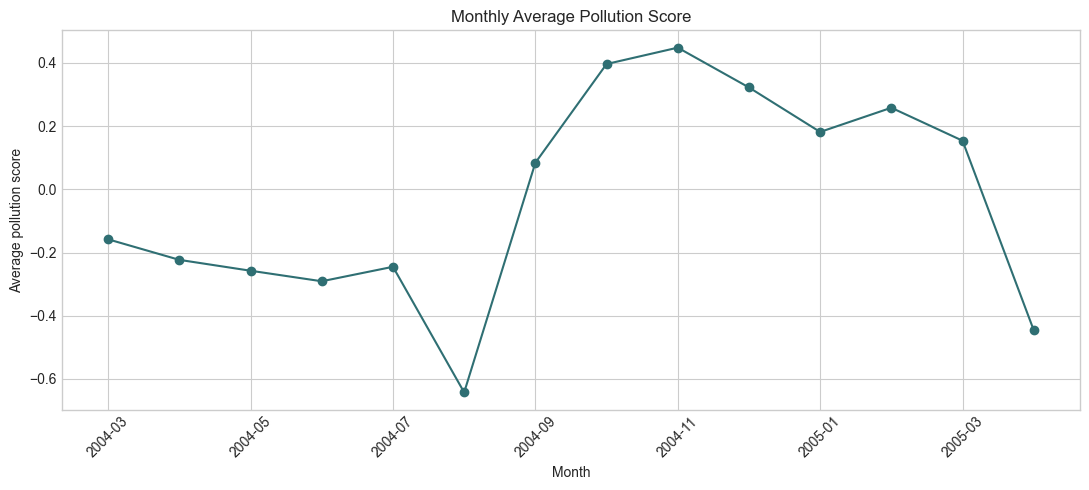

In [35]:
fig, ax = plt.subplots(figsize=(11, 5))
monthly_pollution['pollution_score'].plot(ax=ax, color='#2F6F73', marker='o')
ax.set_title('Monthly Average Pollution Score')
ax.set_xlabel('Month')
ax.set_ylabel('Average pollution score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_monthly_pollution_trend.png', dpi=160)
plt.show()

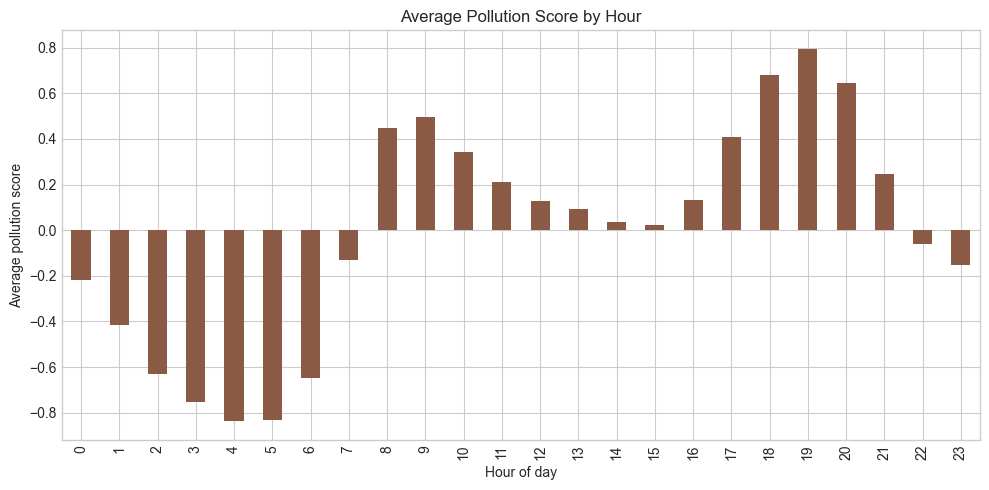

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
hourly_pollution['pollution_score'].plot(kind='bar', ax=ax, color='#8A5A44')
ax.set_title('Average Pollution Score by Hour')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average pollution score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_hourly_pollution_pattern.png', dpi=160)
plt.show()

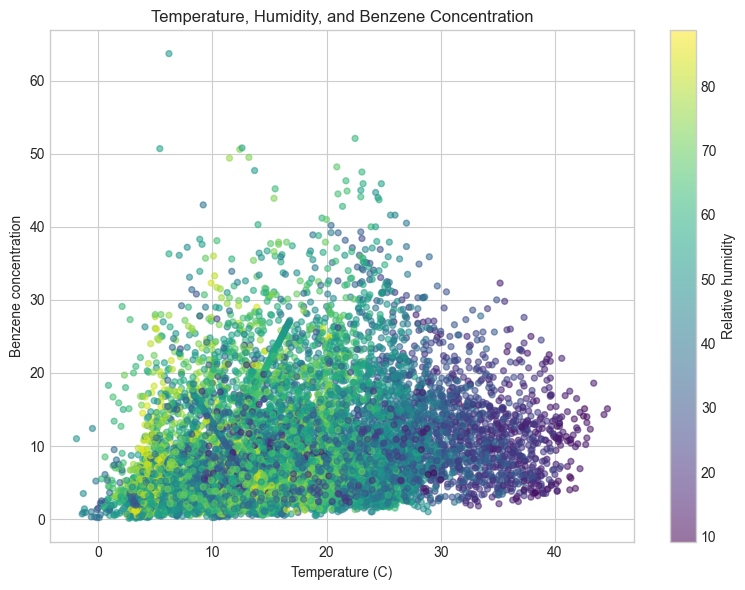

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    df_clean['temperature_c'],
    df_clean['benzene_gt'],
    c=df_clean['relative_humidity'],
    cmap='viridis',
    alpha=0.55,
    s=18
)
ax.set_title('Temperature, Humidity, and Benzene Concentration')
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Benzene concentration')
plt.colorbar(scatter, label='Relative humidity')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_temperature_humidity_benzene_scatter.png', dpi=160)
plt.show()

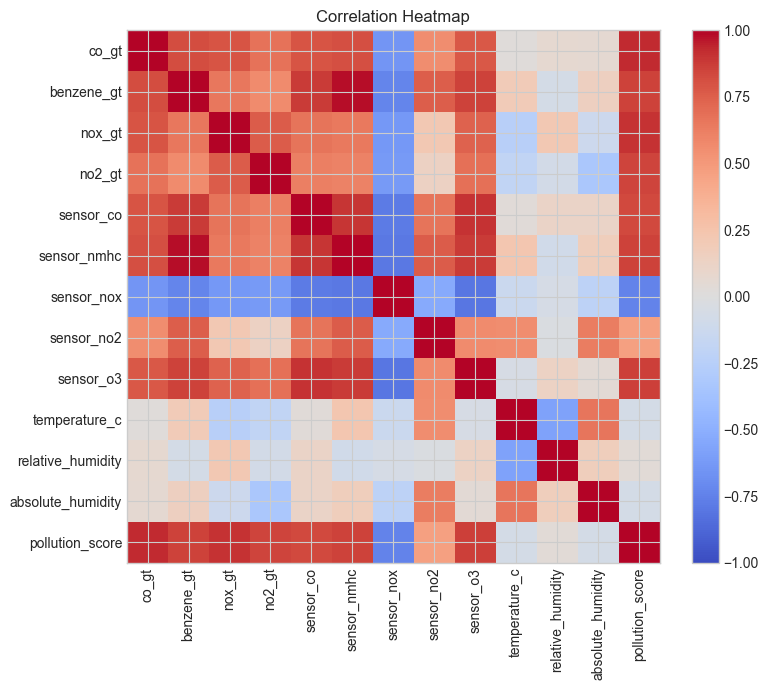

In [38]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlations, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=90)
ax.set_yticklabels(correlation_columns)
ax.set_title('Correlation Heatmap')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_correlation_heatmap.png', dpi=160)
plt.show()

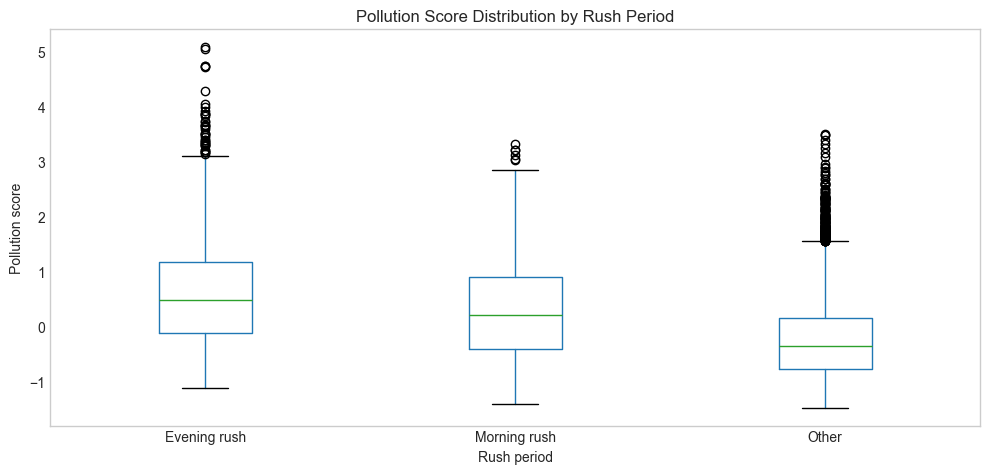

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
df_clean.boxplot(column='pollution_score', by='rush_period', ax=ax, grid=False)
ax.set_title('Pollution Score Distribution by Rush Period')
ax.set_xlabel('Rush period')
ax.set_ylabel('Pollution score')
plt.suptitle('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_rush_period_pollution_boxplot.png', dpi=160)
plt.show()

## Key Findings

1. **Hourly pattern:** Pollution levels can be compared across all 24 hours to identify high-risk periods.
2. **Rush-period effect:** Morning and evening travel periods provide a meaningful comparison against other hours.
3. **Weather relationship:** Temperature, relative humidity, and absolute humidity can be compared with pollutant concentration.
4. **Sensor relationships:** Sensor readings are strongly useful for understanding pollutant behavior because they track related chemical concentration patterns.
5. **Data quality:** The dataset includes meaningful missing values, so replacing `-200` and interpolating numeric variables is an important cleaning step.

## Limitations

This dataset comes from one monitoring setup and one time period, so the results may not represent every city or region. Missing values were marked with `-200`, and interpolation is a practical cleaning choice, but it can smooth extreme pollution events. Correlation analysis shows relationships, but it does not prove causation.